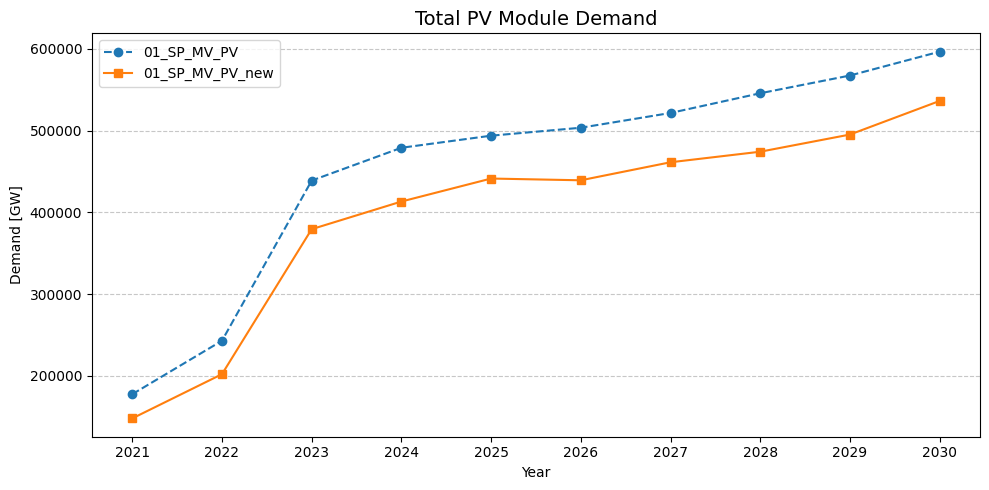

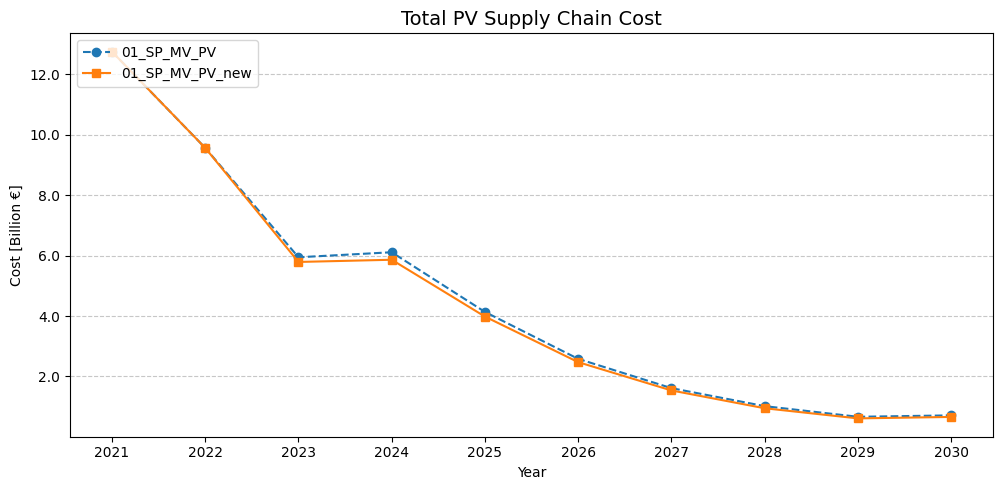

In [10]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import matplotlib.ticker as ticker
from zen_garden.postprocess.results import Results

# === Dataset Setup ===
dataset_name_1 = '01_SP_MV_PV'
dataset_name_2 = '01_SP_MV_PV_new'
r1 = Results(os.path.join("outputs", dataset_name_1))
r2 = Results(os.path.join("outputs", dataset_name_2))

# === Save Path Settings ===
save_plots = True
save_path = Path(r"C:\Users\nicol\OneDrive\Desktop\Semester_project\Plots_and_Figures\SCM_plots\pv_comparison")
csv_export_path = Path(r"C:\Users\nicol\OneDrive\Desktop\Semester_project\Plots_and_Figures\device_demand_data")

if save_plots:
    os.makedirs(save_path, exist_ok=True)
    os.makedirs(csv_export_path, exist_ok=True)

# === Style Settings ===
start_year = 2021
marker_styles = {dataset_name_1: 'o', dataset_name_2: 's'}
colors = {dataset_name_1: '#1f77b4', dataset_name_2: '#ff7f0e'}
linestyles = {dataset_name_1: '--', dataset_name_2: '-'}
line_widths = {dataset_name_1: 1.5, dataset_name_2: 1.5}

# === Load and Filter Demand ===
demand1 = r1.get_full_ts("demand").reset_index()
demand2 = r2.get_full_ts("demand").reset_index()

demand_pv_1 = demand1[demand1["carrier"].str.lower() == "pv_module"]
demand_pv_2 = demand2[demand2["carrier"].str.lower() == "pv_module"]

time_cols = [col for col in demand_pv_1.columns if isinstance(col, (int, float))]

# === Total Demand Plot ===
def plot_total_pv_demand():
    total1 = demand_pv_1[time_cols].sum()
    total2 = demand_pv_2[time_cols].sum()

    plt.figure(figsize=(10, 5))
    plt.plot(time_cols, total1, label=dataset_name_1, color=colors[dataset_name_1],
             linestyle=linestyles[dataset_name_1], marker=marker_styles[dataset_name_1])
    plt.plot(time_cols, total2, label=dataset_name_2, color=colors[dataset_name_2],
             linestyle=linestyles[dataset_name_2], marker=marker_styles[dataset_name_2])

    plt.title("Total PV Module Demand", fontsize=14)
    plt.xlabel("Year")
    plt.ylabel("Demand [GW]")
    plt.grid(axis='y', linestyle="--", alpha=0.7)
    plt.legend(loc='upper left')
    plt.tight_layout()
    plt.xticks(ticks=time_cols, labels=[str(start_year + i) for i in range(len(time_cols))])

    if save_plots:
        plt.savefig(save_path / "pv_module_demand_total.pdf", format='pdf', bbox_inches='tight')
    plt.show()

def plot_total_pv_cost():
    cost1 = r1.get_full_ts("cost_total").reset_index()
    cost2 = r2.get_full_ts("cost_total").reset_index()

    # Filter if carrier column exists
    if "carrier" in cost1.columns:
        cost1 = cost1[cost1["carrier"].str.lower() == "pv_module"]
    if "carrier" in cost2.columns:
        cost2 = cost2[cost2["carrier"].str.lower() == "pv_module"]

    # Ensure year is calendar-based
    if "year" in cost1.columns:
        cost1["year"] = cost1["year"] + start_year
        cost2["year"] = cost2["year"] + start_year
    else:
        print("❌ 'year' column not found in cost_total data. Cannot plot.")
        return

    # Convert cost to B€
    cost1["value"] = cost1["value"] / 1e6
    cost2["value"] = cost2["value"] / 1e6

    years = sorted(set(cost1["year"]).union(set(cost2["year"])))

    # Plotting
    plt.figure(figsize=(10, 5))
    plt.plot(cost1["year"], cost1["value"], label=dataset_name_1, color=colors[dataset_name_1],
             linestyle=linestyles[dataset_name_1], marker=marker_styles[dataset_name_1])
    plt.plot(cost2["year"], cost2["value"], label=dataset_name_2, color=colors[dataset_name_2],
             linestyle=linestyles[dataset_name_2], marker=marker_styles[dataset_name_2])

    plt.title("Total PV Supply Chain Cost", fontsize=14)
    plt.xlabel("Year")
    plt.ylabel("Cost [Billion €]")
    plt.grid(axis='y', linestyle="--", alpha=0.7)
    plt.legend(loc='upper left')
    plt.tight_layout()
    plt.xticks(ticks=years, labels=[str(y) for y in years])

    # Format y-axis with commas and one decimal
    ax = plt.gca()
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:,.1f}'))

    if save_plots:
        plt.savefig(save_path / "pv_module_cost_total.pdf", format='pdf', bbox_inches='tight')

    plt.show()



# === Run All ===
plot_total_pv_demand()
plot_total_pv_cost()
